# 02 — İşlem ve Ürün EDA'sı

## Amaç

Bu notebook, işlem satırlarını yalnızca teknik açıdan değil, müşteri davranışı ve
proje hedefi açısından inceler. İşlem tablosu ürün tablosuyla birleştirilerek yüksek
miktarların, yüksek satışların ve kategori tercihlerinin iş anlamı araştırılır.

### Cevaplanacak sorular

1. Satış, sepet ve aktif müşteri sayısı zaman içinde nasıl değişiyor?
2. `quantity`, `sales_value` ve indirim değişkenlerinin dağılımları nasıl?
3. Aykırı görünen işlemler veri hatası mı, belirli ürün kategorileri mi?
4. Hangi departman ve marka türleri satışta öne çıkıyor?
5. Hanelerin recency, frequency ve monetary davranışları nasıl dağılıyor?
6. Pasifleşme modelinde kullanılabilecek hangi davranış değişkenleri anlamlı görünüyor?

> Buradaki analiz açıklayıcıdır. Nihai model özellikleri daha sonra yalnızca gözlem
> dönemindeki veriden üretilecektir; böylece veri sızıntısı önlenecektir.


## 1. Kütüphaneler, yollar ve verinin yüklenmesi


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def first_existing_path(candidates):
    """İlk bulunan klasörü döndürür; bulunamazsa açıklayıcı hata verir."""
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Veri klasörü bulunamadı. Beklenen seçenekler: "
        + ", ".join(map(str, candidates))
    )


RAW_PATH = first_existing_path([
    "data/raw",
    "../data/raw",
    "data_raw",
    "../data_raw",
])

if RAW_PATH.name == "raw":
    DATA_ROOT = RAW_PATH.parent
else:
    DATA_ROOT = RAW_PATH.parent / "data"

PROCESSED_PATH = DATA_ROOT / "processed"
INTERIM_PATH = DATA_ROOT / "interim"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

print(f"Ham veri klasörü : {RAW_PATH.resolve()}")
print(f"İşlenmiş veri    : {PROCESSED_PATH.resolve()}")
print(f"Ara çıktılar     : {INTERIM_PATH.resolve()}")


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", palette="deep")


Ham veri klasörü : C:\Users\ed024981\Desktop\Miuul_project\data\raw
İşlenmiş veri    : C:\Users\ed024981\Desktop\Miuul_project\data\processed
Ara çıktılar     : C:\Users\ed024981\Desktop\Miuul_project\data\interim


In [2]:
def load_prepared_table(table_name):
    """Önce 01 notebook'unun ürettiği Parquet'i, yoksa ham CSV'yi okur."""
    parquet_path = INTERIM_PATH / f"{table_name}.parquet"
    csv_path = RAW_PATH / f"{table_name}.csv"

    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        source = parquet_path
    elif csv_path.exists():
        df = pd.read_csv(csv_path, low_memory=False)
        df.columns = (
            df.columns.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "_", regex=True)
        )
        source = csv_path
    else:
        raise FileNotFoundError(
            f"{table_name} için Parquet veya CSV bulunamadı. "
            "Önce 01_data_preparation.ipynb notebook'unu çalıştırın."
        )

    print(f"{table_name:20} <- {source} | {df.shape}")
    return df


In [3]:
transaction_data = load_prepared_table("transaction_data")
product = load_prepared_table("product")

required_transaction_cols = {
    "household_key", "basket_id", "day", "product_id", "quantity",
    "sales_value", "store_id", "retail_disc", "trans_time", "week_no",
    "coupon_disc", "coupon_match_disc",
}
required_product_cols = {
    "product_id", "department", "commodity_desc", "sub_commodity_desc",
    "manufacturer", "brand", "curr_size_of_product",
}

assert required_transaction_cols.issubset(transaction_data.columns)
assert required_product_cols.issubset(product.columns)
assert product["product_id"].is_unique, "product_id benzersiz olmalıdır."


transaction_data     <- ..\data\interim\transaction_data.parquet | (2595732, 12)
product              <- ..\data\interim\product.parquet | (92353, 7)


In [4]:
# User Guide'daki satış ve indirim tanımlarına göre türetilen değişkenler
transaction_data = transaction_data.copy()

# sales_value: perakendecinin işlemden elde ettiği tutar
transaction_data["retailer_revenue"] = transaction_data["sales_value"]

# Üretici kuponu perakendeciye geri ödendiği için müşterinin ödediği tutar
transaction_data["customer_paid_value"] = (
    transaction_data["sales_value"]
    + transaction_data["coupon_disc"]
)

# İndirimler uygulanmadan önceki toplam tutar
transaction_data["regular_shelf_value"] = (
    transaction_data["sales_value"]
    - transaction_data["retail_disc"]
    - transaction_data["coupon_match_disc"]
)

# Müşteriye sağlanan toplam indirim
transaction_data["total_discount_amount"] = -(
    transaction_data["retail_disc"]
    + transaction_data["coupon_disc"]
    + transaction_data["coupon_match_disc"]
)

# quantity=0 kayıtlarında sıfıra bölme oluşmasını engelle
valid_quantity = transaction_data["quantity"].where(
    transaction_data["quantity"] > 0
)

# User Guide'da verilen birim fiyat formülleri
transaction_data["loyalty_card_unit_price"] = (
    transaction_data["sales_value"]
    - (
        transaction_data["retail_disc"]
        + transaction_data["coupon_match_disc"]
    )
) / valid_quantity

transaction_data["non_loyalty_unit_price"] = (
    transaction_data["sales_value"]
    - transaction_data["coupon_match_disc"]
) / valid_quantity

In [5]:
derived_value_check = transaction_data[
    [
        "sales_value",
        "customer_paid_value",
        "regular_shelf_value",
        "total_discount_amount",
    ]
].describe().T

display(derived_value_check)

print(
    "Negatif müşteri ödeme tutarı:",
    transaction_data["customer_paid_value"].lt(0).sum()
)

,count,mean,std,min,25%,50%,75%,max
sales_value,"2,595,732.000",3.104,4.182,0.000,1.290,2.000,3.490,840.000
customer_paid_value,"2,595,732.000",3.088,4.180,-37.930,1.250,2.000,3.490,840.000
regular_shelf_value,"2,595,732.000",3.646,4.655,-0.010,1.590,2.590,3.990,840.000
total_discount_amount,"2,595,732.000",0.558,1.280,-3.990,-0.000,0.070,0.700,180.000


Negatif müşteri ödeme tutarı: 5819


In [6]:
payment_quality_flags = pd.Series({
    "negative_customer_paid_lines": int(
        transaction_data["customer_paid_value"].lt(0).sum()
    ),
    "zero_customer_paid_lines": int(
        transaction_data["customer_paid_value"].eq(0).sum()
    ),
    "negative_regular_shelf_lines": int(
        transaction_data["regular_shelf_value"].lt(0).sum()
    ),
    "negative_total_discount_lines": int(
        transaction_data["total_discount_amount"].lt(0).sum()
    ),
    "quantity_zero_unit_prices": int(
        transaction_data["quantity"].eq(0).sum()
    ),
})

payment_quality_flags.to_frame("count")

,count
negative_customer_paid_lines,5819
zero_customer_paid_lines,15759
negative_regular_shelf_lines,17
negative_total_discount_lines,36
quantity_zero_unit_prices,14466


## 2. Değişkenlerin iş anlamı

- `household_key`: Haneyi tanımlar; modelleme birimi olacaktır.
- `basket_id`: Bir alışveriş/sepet olayını tanımlar.
- `day`, `week_no`: Zaman sırasını verir. Gerçek takvim tarihi bulunmaz.
- `product_id`: Ürün tablosuna bağlanan kimliktir.
- `quantity`: Satın alınan miktardır; benzin gibi ürünlerde birim farklılığı nedeniyle
  çok yüksek olabilir.

- `retail_disc`: Sadakat programı/perakendeci indirimi.
- `coupon_disc`: Üretici kuponu indirimi.
- `coupon_match_disc`: Perakendecinin üretici kuponuna ek eşleştirme indirimi.
- `department`, `commodity_desc`, `sub_commodity_desc`: Ürün hiyerarşisidir.
- `brand`: National veya Private marka türüdür.

- `sales_value`: Müşterinin doğrudan ödediği tutar değil, perakendecinin işlemden
  elde ettiği tutardır. Üretici kuponu kullanıldığında kupon bedeli üretici
  tarafından perakendeciye geri ödendiği için müşteri ödemesi daha düşük olabilir.
- `retailer_revenue`: `sales_value` değişkeninin anlamını açık biçimde göstermek
  için oluşturulan perakendeci geliridir.
- `customer_paid_value`: Müşterinin kupon sonrası ödediği tahmini tutardır ve
  `sales_value + coupon_disc` biçiminde hesaplanır.
- `regular_shelf_value`: Perakendeci ve kupon eşleştirme indirimlerinden önceki
  toplam ürün tutarıdır.
- `total_discount_amount`: Perakendeci indirimi, üretici kuponu ve kupon eşleştirme
  indiriminin müşteriye sağladığı toplam avantajdır.
İndirimler çoğunlukla negatif işaretle tutulduğu için negatif değer tek başına veri
hatası değildir.

Bu notebook'ta perakendeci performansını inceleyen analizlerde
`retailer_revenue`, müşteri davranışını inceleyen sepet ve hane analizlerinde ise
`customer_paid_value` kullanılacaktır. Böylece perakendecinin elde ettiği gelir
ile müşterinin ödediği tutar birbirine karıştırılmayacaktır.

## 3. Sayısal dağılımlar


In [7]:
metric_cols = [
    "quantity",
    "retailer_revenue",
    "customer_paid_value",
    "regular_shelf_value",
    "total_discount_amount",
    "retail_disc",
    "coupon_disc",
    "coupon_match_disc",
]

transaction_summary = (
    transaction_data[metric_cols]
    .describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
    .T
)
transaction_summary["skew"] = transaction_data[metric_cols].skew()
transaction_summary


,count,mean,std,min,1%,5%,50%,95%,99%,max,skew
quantity,"2,595,732.000",100.429,"1,153.436",0.000,1.000,1.000,1.000,3.000,10.000,"89,638.000",13.643
retailer_revenue,"2,595,732.000",3.104,4.182,0.000,0.200,0.590,2.000,7.990,20.000,840.000,15.907
customer_paid_value,"2,595,732.000",3.088,4.180,-37.930,0.200,0.590,2.000,7.990,20.000,840.000,15.895
regular_shelf_value,"2,595,732.000",3.646,4.655,-0.010,0.300,0.670,2.590,9.540,23.140,840.000,13.589
total_discount_amount,"2,595,732.000",0.558,1.280,-3.990,0.000,-0.000,0.070,2.300,5.010,180.000,13.004
retail_disc,"2,595,732.000",-0.539,1.249,-180.000,-4.990,-2.190,-0.010,0.000,0.000,3.990,-13.350
coupon_disc,"2,595,732.000",-0.016,0.217,-55.930,-0.500,0.000,0.000,0.000,0.000,0.000,-44.207
coupon_match_disc,"2,595,732.000",-0.003,0.040,-7.700,0.000,0.000,0.000,0.000,0.000,0.000,-24.435


In [8]:
discount_usage_summary = pd.DataFrame({
    "discount_type": ["retail_disc", "coupon_disc", "coupon_match_disc"],
    "transaction_lines_with_discount": [
        transaction_data["retail_disc"].lt(0).sum(),
        transaction_data["coupon_disc"].lt(0).sum(),
        transaction_data["coupon_match_disc"].lt(0).sum(),
    ],
    "unique_households": [
        transaction_data.loc[transaction_data["retail_disc"].lt(0), "household_key"].nunique(),
        transaction_data.loc[transaction_data["coupon_disc"].lt(0), "household_key"].nunique(),
        transaction_data.loc[transaction_data["coupon_match_disc"].lt(0), "household_key"].nunique(),
    ],
    "total_discount_amount": [
        -transaction_data["retail_disc"].clip(upper=0).sum(),
        -transaction_data["coupon_disc"].clip(upper=0).sum(),
        -transaction_data["coupon_match_disc"].clip(upper=0).sum(),
    ],
})
discount_usage_summary["line_rate"] = (
    discount_usage_summary["transaction_lines_with_discount"] / len(transaction_data)
)
discount_usage_summary


,discount_type,transaction_lines_with_discount,unique_households,total_discount_amount,line_rate
0,retail_disc,1303026,2500,"1,398,343.370",0.502
1,coupon_disc,36422,1858,"42,611.540",0.014
2,coupon_match_disc,17449,1291,"7,575.810",0.007


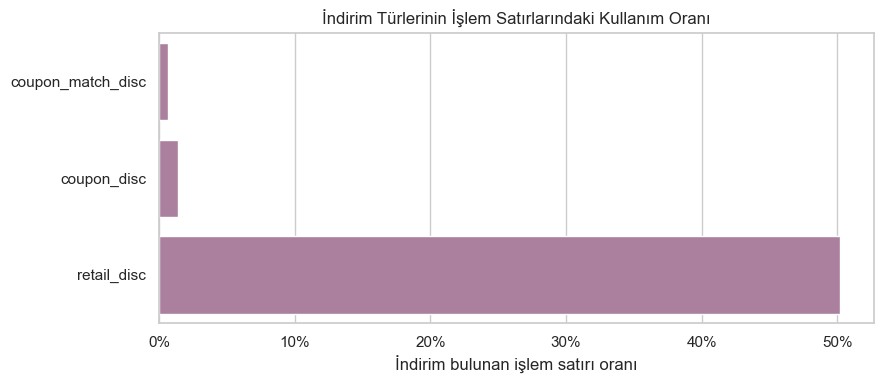

In [9]:
plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=discount_usage_summary.sort_values("line_rate"),
    x="line_rate", y="discount_type", color="#B279A2"
)
ax.set_title("İndirim Türlerinin İşlem Satırlarındaki Kullanım Oranı")
ax.set_xlabel("İndirim bulunan işlem satırı oranı")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()


### Sayısal dağılımlara ilişkin bulgular

`quantity` değişkeninin medyanı 1 olmasına rağmen ortalaması yaklaşık 100 ve
maksimumu 89.638'dir. Ortalama ile medyan arasındaki büyük fark, dağılımın güçlü
biçimde sağa çarpık olduğunu göstermektedir. Bununla birlikte yüksek miktarlar
belirli ürünlerde farklı ölçü birimlerinden kaynaklanabileceği için doğrudan veri
hatası olarak değerlendirilmemelidir.

Perakendecinin işlem satırı başına ortalama geliri 3,104, müşterinin tahmini ödeme
tutarı ise 3,088'dir. Her iki değişkenin medyanı 2,00'dır. İndirim öncesi raf
tutarının medyanının 2,59 olması, perakendeci ve kupon eşleştirme indirimlerinin
fiyat üzerindeki etkisini göstermektedir.

Perakendeci indirimi işlem satırlarının yaklaşık %50,2'sinde görülmekte ve
2.500 hanenin tamamına ulaşmaktadır. Üretici kuponu işlem satırlarının yaklaşık
%1,4'ünde, kupon eşleştirme indirimi ise yaklaşık %0,7'sinde kullanılmıştır.
Dolayısıyla kupon değişkenlerinin çoğunlukla sıfır olması bir veri kalite sorunu
değil, veri setinin doğal yapısıdır.

### Analitik karar

Çarpık parasal değişkenlerde logaritmik dönüşüm veya sağlam ölçekleme
değerlendirilebilir. Kupon davranışı ise yalnızca toplam tutarla değil; kupon
kullanılan işlem oranı, kupon kullanılan sepet oranı ve indirimin toplam
harcamaya oranı gibi özelliklerle temsil edilmelidir.

Sıfır ağırlıklı kupon değişkenlerine standart IQR yöntemi doğrudan
uygulanmayacaktır; aksi halde olağan kupon kullanımları yanlışlıkla aykırı gözlem
olarak işaretlenebilir.


## 4. Yüksek miktar ve yüksek satış kayıtlarının ürünlerle açıklanması


In [10]:
transaction_product = transaction_data.merge(
    product[
        [
            "product_id", "department", "commodity_desc",
            "sub_commodity_desc", "brand", "manufacturer",
            "curr_size_of_product",
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one",
)

print(f"Birleşme öncesi satır: {len(transaction_data):,}")
print(f"Birleşme sonrası satır: {len(transaction_product):,}")
print(f"Kategori bilgisi bulunmayan satır: {transaction_product['department'].isna().sum():,}")

display(
    transaction_product.sort_values("quantity", ascending=False)
    .head(20)[
        [
            "household_key", "basket_id", "day", "product_id", "quantity",
            "sales_value", "department", "commodity_desc", "sub_commodity_desc",
        ]
    ]
)

display(
    transaction_product.sort_values("retailer_revenue", ascending=False)
    .head(20)[
        [
            "household_key","basket_id","day",
            "product_id","quantity",
            "retailer_revenue","customer_paid_value","total_discount_amount",
            "department","commodity_desc","sub_commodity_desc",
        ]
    ]
)


Birleşme öncesi satır: 2,595,732
Birleşme sonrası satır: 2,595,732
Kategori bilgisi bulunmayan satır: 7,839


,household_key,basket_id,day,product_id,quantity,sales_value,department,commodity_desc,sub_commodity_desc
1750942,630,34749153595,503,6534178,89638,250.000,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
468356,2407,29392047893,181,6544236,85055,210.000,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
481876,630,29484790880,185,6534178,61335,150.210,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
166536,149,28210551971,103,6534178,51912,110.000,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
1340882,193,32956767959,402,6534178,48073,121.100,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
2472791,2133,41904760458,682,6534178,45475,100.000,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
1560340,149,33768630428,456,6534178,41833,115.000,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
376686,149,29035716247,158,6534178,41686,100.000,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
156049,1406,28167562655,99,6544236,41485,85.000,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED
87625,107,27865225627,74,6534178,39365,72.000,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED


,household_key,basket_id,day,product_id,quantity,retailer_revenue,customer_paid_value,total_discount_amount,department,commodity_desc,sub_commodity_desc
1085442,1609,32006114302,339,12484608,3,840.000,840.000,-0.000,MISC SALES TRAN,COUPON/MISC ITEMS,ELECTRONIC GIFT CARDS ACTIVATI
2030766,346,40387571385,574,948670,5,631.800,631.800,-0.000,DRUG GM,TICKETS,TICKETS
655985,125,30515165970,230,1089093,2,505.000,505.000,-0.000,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION
1152895,374,32187143334,355,13212959,1,499.990,499.990,50.000,DRUG GM,SPRING/SUMMER SEASONAL,OUTDOOR ROLL-UP BLINDS
547657,125,30031850855,201,1089093,1,455.000,455.000,-0.000,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION
526495,2080,29712930072,196,1089093,1,430.000,430.000,-0.000,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION
3600,64,27093315740,10,1089093,1,400.000,400.000,-0.000,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION
2352647,2395,41531856879,654,1089093,1,380.000,380.000,-0.000,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION
1366400,1109,33028063235,408,13506935,1,329.990,329.990,-0.000,DRUG GM,SPRING/SUMMER SEASONAL,PATIO SETS
807063,2032,31007917779,269,9296877,25,324.750,324.750,-0.000,FLORAL,GIFT & FRUIT BASKETS,FRUIT BASKETS


### Akaryakıt kayıtlarında miktar biriminin incelenmesi

`quantity` değişkeninin medyanı 1 olmasına rağmen maksimum değerinin 89.638 olması,
dağılımın güçlü biçimde sağa çarpık görünmesine neden olmaktadır. Yüksek miktarlı
satırların ürün bilgileri incelendiğinde bu kayıtların büyük bölümünün
`GASOLINE-REG UNLEADED` ürünlerine ait olduğu görülmektedir.

Bu durum, akaryakıt miktarının market ürünlerindeki adet bilgisinden farklı bir
ölçü birimiyle kaydedilmiş olabileceğini göstermektedir. Bu varsayımı kontrol etmek
için akaryakıtla ilişkili ürünler belirlenmiş, ham `quantity` değerleri 1.000'e
bölünerek tahmini galon hacmi oluşturulmuş ve `sales_value / tahmini galon`
oranının dağılımı incelenmiştir.

Bu analiz doğrudan bir veri temizleme işlemi değildir. Amaç, yüksek miktarların
veri hatası mı yoksa farklı bir kayıt biçiminden mi kaynaklandığını belirlemektir.

In [11]:
fuel_mask = (
    transaction_product["department"]
    .fillna("")
    .str.contains(r"KIOSK-GAS|FUEL", case=False, regex=True)
    |
    transaction_product["sub_commodity_desc"]
    .fillna("")
    .str.contains("GASOLINE", case=False, regex=False)
)

transaction_product["is_fuel"] = fuel_mask.astype("int8")

# Market ürün adedi ve yakıt hacmi ayrı tutulur.
transaction_product["item_units"] = np.where(
    ~fuel_mask,
    transaction_product["quantity"],
    np.nan
)

transaction_product["fuel_volume_gallon"] = np.where(
    fuel_mask,
    transaction_product["quantity"] / 1000,
    np.nan
)

fuel_check = transaction_product.loc[
    fuel_mask
    & transaction_product["quantity"].gt(0)
    & transaction_product["sales_value"].gt(0)
].copy()

fuel_check["sales_per_gallon"] = (
    fuel_check["sales_value"]
    / fuel_check["fuel_volume_gallon"]
)

print(f"Yakıt işlem satırı: {fuel_mask.sum():,}")
print(
    "Yakıt ürünü:",
    transaction_product.loc[fuel_mask, "product_id"].nunique()
)

fuel_check["sales_per_gallon"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

Yakıt işlem satırı: 24,962
Yakıt ürünü: 35


count    24,962.000
mean      1,189.633
std       4,962.020
min           1.659
1%            1.839
25%           2.108
50%           2.309
75%           2.699
99%      25,000.000
max     100,000.000
Name: sales_per_gallon, dtype: float64

In [28]:
fuel_check["plausible_gallon_price"] = (
    fuel_check["sales_per_gallon"].between(0.5, 10)
)

fuel_product_check = (
    fuel_check.groupby(
        [
            "product_id",
            "department",
            "commodity_desc",
            "sub_commodity_desc",
        ],
        dropna=False,
    )
    .agg(
        transaction_lines=("product_id", "size"),
        median_raw_quantity=("quantity", "median"),
        min_raw_quantity=("quantity", "min"),
        max_raw_quantity=("quantity", "max"),
        median_sales_value=("sales_value", "median"),
        median_sales_per_gallon=("sales_per_gallon", "median"),
        plausible_price_share=("plausible_gallon_price", "mean"),
    )
    .sort_values(
        ["plausible_price_share", "transaction_lines"],
        ascending=[False, False],
    )
    .reset_index()
)

fuel_product_check

,product_id,department,commodity_desc,sub_commodity_desc,transaction_lines,median_raw_quantity,min_raw_quantity,max_raw_quantity,median_sales_value,median_sales_per_gallon,plausible_price_share
0,6534178,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,19820,"10,568.000",10,89638,24.480,2.259,1.000
1,6533889,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,1453,"12,953.000",31,32035,31.800,2.417,1.000
2,6534166,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,1206,"11,680.500",23,36140,27.070,2.339,1.000
3,1404121,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,176,"9,049.500",1470,25750,20.000,2.269,1.000
4,6544236,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,136,"20,051.000",3510,85055,51.010,2.649,1.000
5,397896,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,122,"11,144.000",1684,25567,25.095,2.239,1.000
6,480014,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,43,"10,823.000",2438,20919,23.260,2.069,1.000
7,5668996,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,42,"6,421.500",2106,29945,15.150,2.289,1.000
8,5703832,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,37,"11,400.000",3334,20784,27.650,2.399,1.000
9,1426702,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,35,"13,703.000",5377,25652,32.320,2.429,1.000


### Akaryakıt miktarlarına ilişkin bulgular ve analitik karar

Ürün açıklamalarına göre 24.962 işlem satırı ve 35 ürün akaryakıtla ilişkili olarak
belirlenmiştir. Ürün düzeyindeki inceleme, bu kayıtların tek bir miktar sistemine
sahip olmadığını göstermektedir:

- 27 ürüne ait 23.153 işlem satırında ham miktarlar çoğunlukla binlerle ifade
  edilmektedir. Bu kayıtlar 1.000'e bölündüğünde elde edilen galon başına
  `sales_value` değerleri makul bir aralığa gelmektedir.
- En yüksek miktarlı kayıtta `quantity=89.638` ve `sales_value=250` değerleri
  bulunmaktadır. Miktarın 1.000'e bölünmesiyle 89,638 galon ve yaklaşık
  2,79 birim/galon sonucu elde edilmektedir. Bu bulgu, yüksek miktarın veri
  hatasından çok farklı bir ölçü biriminden kaynaklandığını desteklemektedir.
- 8 ürüne ait 1.809 işlem satırında ise `quantity=1` olmasına rağmen
  `sales_value` 6–100 aralığında değişmektedir. Bu satırların 1.000'e bölünmesi
  gerçekçi olmayan galon başına değerler üretmektedir. Dolayısıyla bu kayıtlar
  hacimle kaydedilmiş yakıt satışı olarak yorumlanmamalıdır.

Bu sonuçlara dayanarak bütün akaryakıt satırlarına aynı dönüşüm uygulanmayacaktır.
Yalnızca hacimle kaydedildiği doğrulanan işlemlerde `quantity / 1000` dönüşümü
kullanılacaktır. Birim veya sabit tutar biçiminde kaydedilen yakıt ilişkili
işlemler ise ayrı bir kayıt türü olarak korunacaktır.

Akaryakıt işlemleri veri setinden silinmeyecek; müşteri harcaması ve ziyaret
davranışında kullanılmaya devam edecektir. Bununla birlikte yakıt hacmi, market
ürünü adediyle toplanmayacak ve tüm ürünlere ortak bir IQR üst sınırı
uygulanmayacaktır.

In [12]:
negative_payment_rows = (
    transaction_product.loc[
        transaction_product["customer_paid_value"].lt(0),
        [
            "household_key",
            "basket_id",
            "day",
            "product_id",
            "quantity",
            "sales_value",
            "retail_disc",
            "coupon_disc",
            "coupon_match_disc",
            "customer_paid_value",
            "total_discount_amount",
            "department",
            "commodity_desc",
            "sub_commodity_desc",
        ],
    ]
    .sort_values("customer_paid_value")
)

print(
    f"Negatif müşteri ödeme tutarına sahip işlem satırı: "
    f"{len(negative_payment_rows):,}"
)

display(negative_payment_rows.head(20))

Negatif müşteri ödeme tutarına sahip işlem satırı: 5,819


,household_key,basket_id,day,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,customer_paid_value,total_discount_amount,department,commodity_desc,sub_commodity_desc
1343620,679,32957147025,403,5978656,0,0.000,0.000,-37.930,0.000,-37.930,37.930,NaN,NaN,NaN
1343646,679,32957147063,403,5978656,0,0.000,0.000,-36.500,0.000,-36.500,36.500,NaN,NaN,NaN
2243254,400,41124522239,627,5978656,0,0.000,0.000,-31.460,0.000,-31.460,31.460,NaN,NaN,NaN
1813442,2467,35386596854,519,5978656,0,0.000,0.000,-30.960,0.000,-30.960,30.960,NaN,NaN,NaN
1933657,2130,40085400702,550,5978656,0,0.000,0.000,-29.650,0.000,-29.650,29.650,NaN,NaN,NaN
1409415,2111,33155686054,418,5978656,0,0.000,0.000,-27.000,0.000,-27.000,27.000,NaN,NaN,NaN
963046,1463,31553513664,308,5978656,0,0.000,0.000,-25.990,0.000,-25.990,25.990,NaN,NaN,NaN
1497739,131,33460888523,441,5978656,0,0.000,0.000,-25.980,0.000,-25.980,25.980,NaN,NaN,NaN
2155331,979,40765361731,606,5978656,0,0.000,0.000,-21.490,0.000,-21.490,21.490,NaN,NaN,NaN
816776,294,31032765335,271,5978656,0,0.000,0.000,-20.000,0.000,-20.000,20.000,NaN,NaN,NaN


In [13]:
negative_payment_category_summary = (
    negative_payment_rows
    .fillna({"department": "Unknown"})
    .groupby("department")
    .agg(
        negative_line_count=("product_id", "size"),
        unique_baskets=("basket_id", "nunique"),
        unique_households=("household_key", "nunique"),
        total_negative_payment=("customer_paid_value", "sum"),
        total_coupon_discount=("coupon_disc", "sum"),
    )
    .sort_values("negative_line_count", ascending=False)
    .reset_index()
)

negative_payment_category_summary.head(15)

,department,negative_line_count,unique_baskets,unique_households,total_negative_payment,total_coupon_discount
0,Unknown,4945,4945,1169,"-10,306.040","-10,306.040"
1,GROCERY,574,507,285,-348.650,-965.690
2,DRUG GM,254,206,119,-156.450,-404.380
3,MEAT-PCKGD,17,17,16,-12.930,-28.630
4,SEAFOOD-PCKGD,11,10,5,-13.250,-64.180
5,DELI,7,7,7,-4.360,-8.030
6,PRODUCE,6,6,4,-4.410,-15.770
7,COUP/STR & MFG,3,3,3,-1.080,-3.080
8,COSMETICS,2,2,2,-0.640,-7.100


### İşlem–ürün birleşmesine ilişkin bulgular

İşlem–ürün birleşmesi öncesinde ve sonrasında satır sayısının 2.595.732 olarak
değişmemesi, birleşmenin beklenen `many-to-one` yapısında gerçekleştiğini ve satır
çoğalması oluşmadığını göstermektedir.

Departman bilgisi bulunmayan 7.839 işlem, eşleşmeyen `product_id` değerlerinden
değil, ürün tablosundaki eksik kategori bilgilerinden kaynaklanmaktadır. Bu
kayıtların kategori analizlerinden tamamen çıkarılması yerine `Unknown` olarak
temsil edilmesi değerlendirilebilir.

### Yüksek miktarlı ve yüksek tutarlı işlemler

En yüksek miktarlı işlemlerin benzin ürünlerine ait olduğu görülmektedir.
Dolayısıyla `quantity` bütün ürünlerde aynı fiziksel anlamı taşıyan standart bir
adet değişkeni değildir. Tüm veri setine ortak bir miktar üst sınırı uygulamak,
geçerli benzin işlemlerinin yanlışlıkla silinmesine neden olabilir.

En yüksek perakendeci gelirine sahip işlemlerde elektronik hediye kartları,
biletler, sezonluk ürünler ve özel işlem kategorileri öne çıkmaktadır. Bu
kayıtların yüksek tutarlı olması, tek başına veri hatası olduklarını göstermez.

### Negatif müşteri ödeme satırlarının açıklanması

Toplam 5.819 işlem satırında negatif `customer_paid_value` tespit edilmiştir.
Bu satırların 4.945'i, yani yaklaşık %85'i, departman bilgisi bulunmayan özel
kupon kayıtlarından oluşmaktadır. En yüksek negatif değerli satırlarda:

- `quantity = 0`,
- `sales_value = 0`,
- Üretici kuponu negatif,
- Ürün kategorisi eksik

olduğu görülmektedir.

Bu yapı, ilgili satırların normal ürün satışından ziyade kuponun muhasebesel
olarak ayrı bir işlem satırında temsil edilmesinden kaynaklandığına işaret
etmektedir. Bu nedenle negatif satır değerleri tek başına müşterinin negatif
ödeme yaptığı şeklinde yorumlanmamalıdır. Müşteri harcaması sepet ve hane
düzeyinde toplulaştırılarak değerlendirilmelidir.

### Feature engineering açısından karar

- Ham toplam miktar yerine sepet sayısı ve farklı ürün sayısı tercih edilebilir.
- Benzin harcaması ayrı bir kategori özelliği olarak üretilebilir.
- Hediye kartları ve özel işlem kategorileri ayrı göstergelerle temsil edilebilir.
- Kategori bilgisi bulunmayan kupon satırları ürün tercihi hesaplamalarına doğrudan
  dahil edilmemelidir.
- Negatif kupon satırları silinmeden önce sepet içindeki diğer ürünlerle birlikte
  değerlendirilmelidir.

## 5. İşlem saati kalite kontrolü ve gün içi dağılım


Geçersiz veya dönüştürülemeyen saat: 0


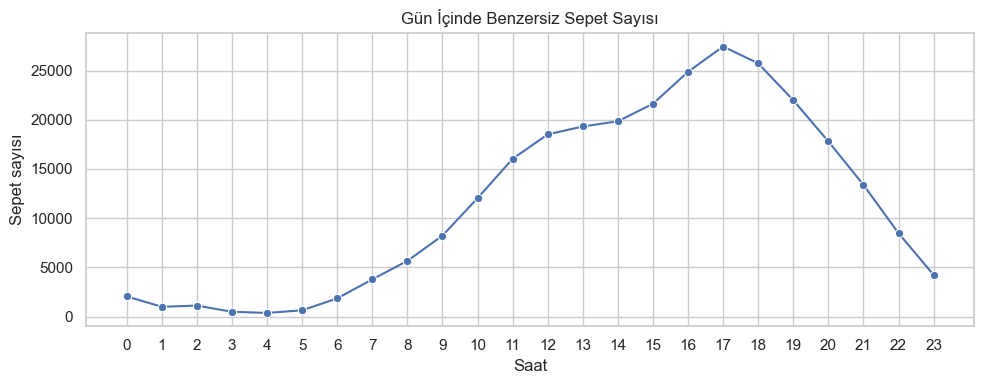

In [14]:
def hhmm_to_minutes(value):
    """HHMM biçimindeki işlem saatini gece yarısından itibaren dakikaya çevirir."""
    if pd.isna(value):
        return np.nan
    value = int(value)
    hour, minute = divmod(value, 100)
    if not (0 <= hour <= 23 and 0 <= minute <= 59):
        return np.nan
    return hour * 60 + minute


transaction_data["transaction_minute"] = transaction_data["trans_time"].map(hhmm_to_minutes)
transaction_data["transaction_hour"] = transaction_data["transaction_minute"] // 60

print(
    "Geçersiz veya dönüştürülemeyen saat:",
    transaction_data["transaction_minute"].isna().sum(),
)

hourly_baskets = (
    transaction_data.dropna(subset=["transaction_hour"])
    .groupby("transaction_hour")["basket_id"]
    .nunique()
    .reset_index(name="basket_count")
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_baskets, x="transaction_hour", y="basket_count", marker="o")
plt.title("Gün İçinde Benzersiz Sepet Sayısı")
plt.xlabel("Saat")
plt.ylabel("Sepet sayısı")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


### Gün içi alışveriş davranışına ilişkin bulgular

Bütün işlem saati değerleri geçerli HHMM formatında dönüştürülmüş ve geçersiz
işlem saati tespit edilmemiştir.

Sepet sayısı gece ve sabahın erken saatlerinde oldukça düşüktür. Alışveriş
yoğunluğu sabah saatlerinden itibaren artmakta, yaklaşık 17.00 civarında en yüksek
seviyesine ulaşmakta ve akşam saatlerinden sonra kademeli olarak azalmaktadır.

Bu örüntü, işlem saatinin müşteri davranışını ayırabilecek bir özellik olduğunu
göstermektedir. Feature engineering aşamasında aşağıdaki değişkenler
değerlendirilebilir:

- En sık alışveriş yapılan saat,
- Sabah, öğle, akşam ve gece alışveriş oranları,
- Akşam saatlerinde yapılan sepetlerin oranı,
- Alışveriş saatlerinin standart sapması,
- Müşterinin düzenli veya değişken saatlerde alışveriş yapması.

Gerçek takvim tarihi ve haftanın günü kesin olarak bilinmediği için hafta içi ve
hafta sonu ayrımı ek bilgi olmadan yapılmayacaktır.

## 6. Haftalık iş metrikleri, panel girişleri ve normalize edilmiş trendler

İlk haftalardaki hızlı artış gerçek müşteri büyümesiyle karıştırılmamalıdır. Her
hanenin ilk görüldüğü hafta hesaplanarak panelin zaman içinde nasıl dolduğu gösterilir.
Ardından satış ve sepet metrikleri aktif hane sayısına bölünür. Böylece toplamların
büyümesi ile hane başına davranış değişimi ayrıştırılır.


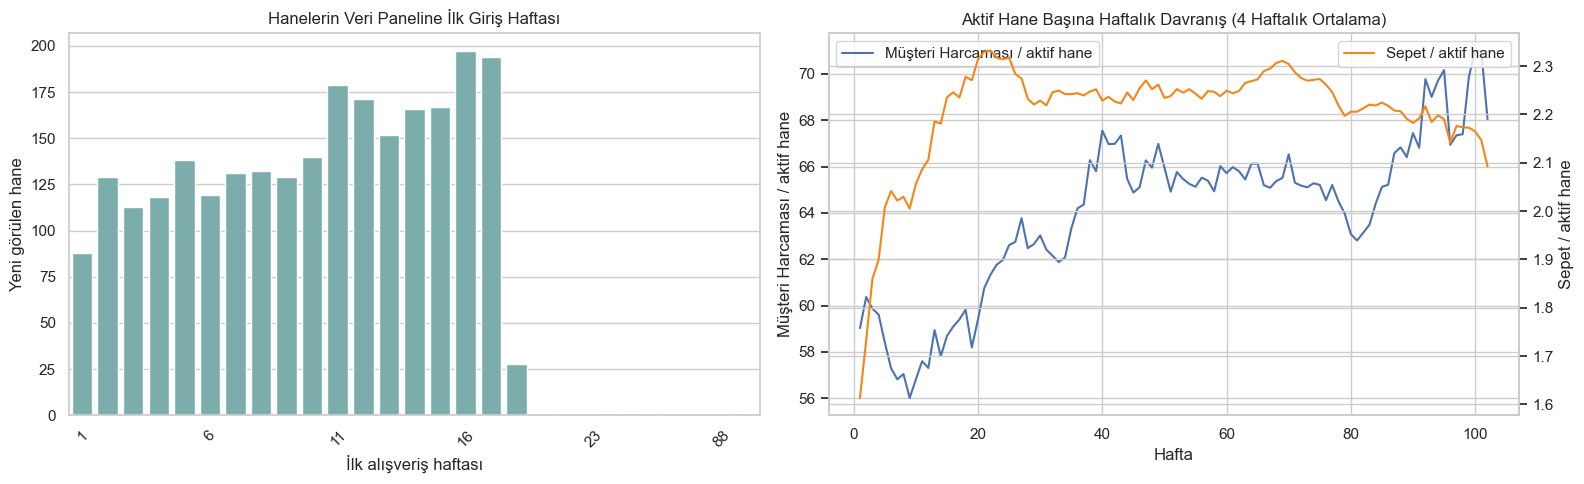

In [15]:
weekly_kpis = (
    transaction_data.groupby("week_no")
    .agg(
        total_retailer_revenue=("retailer_revenue", "sum"),
        total_customer_spend=("customer_paid_value", "sum"),
        total_discount_amount=("total_discount_amount", "sum"),
        unique_baskets=("basket_id", "nunique"),
        active_households=("household_key", "nunique"),
        unique_products=("product_id", "nunique"),
    )
    .reset_index()
)

weekly_kpis["avg_customer_basket_value"] = (
    weekly_kpis["total_customer_spend"]
    / weekly_kpis["unique_baskets"]
)

household_entry = (
    transaction_data.groupby("household_key")["week_no"]
    .min()
    .value_counts()
    .sort_index()
    .rename_axis("first_week")
    .reset_index(name="new_households")
)
household_entry["cumulative_households"] = household_entry["new_households"].cumsum()

normalized_weekly = weekly_kpis.copy()
normalized_weekly["spend_per_active_household"] = (
    normalized_weekly["total_customer_spend"]
    / normalized_weekly["active_households"]
)
normalized_weekly["baskets_per_active_household"] = (
    normalized_weekly["unique_baskets"] / normalized_weekly["active_households"]
)
normalized_weekly["spend_per_active_household_ma4"] = (
    normalized_weekly["spend_per_active_household"]
    .rolling(4, min_periods=1)
    .mean()
)
normalized_weekly["baskets_per_active_household_ma4"] = (
    normalized_weekly["baskets_per_active_household"].rolling(4, min_periods=1).mean()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=household_entry, x="first_week", y="new_households",
    color="#72B7B2", ax=axes[0]
)
axes[0].set_title("Hanelerin Veri Paneline İlk Giriş Haftası")
axes[0].set_xlabel("İlk alışveriş haftası")
axes[0].set_ylabel("Yeni görülen hane")
tick_positions = range(0, len(household_entry), 5)
axes[0].set_xticks(list(tick_positions))
axes[0].set_xticklabels(
    household_entry.iloc[list(tick_positions)]["first_week"].astype(int),
    rotation=45,
)

sns.lineplot(
    data=normalized_weekly, x="week_no", y="spend_per_active_household_ma4",
    label="Müşteri Harcaması / aktif hane", ax=axes[1]
)
ax2 = axes[1].twinx()
sns.lineplot(
    data=normalized_weekly, x="week_no", y="baskets_per_active_household_ma4",
    color="#F58518", label="Sepet / aktif hane", ax=ax2
)
axes[1].set_title("Aktif Hane Başına Haftalık Davranış (4 Haftalık Ortalama)")
axes[1].set_xlabel("Hafta")
axes[1].set_ylabel("Müşteri Harcaması / aktif hane")
ax2.set_ylabel("Sepet / aktif hane")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


### 6.1. Toplam haftalık metrikler

Ham işlem satırı sayısı tek başına yeterli değildir. Haftalık satış, sepet ve aktif
hane sayıları birlikte incelenerek genel trend, dönemsel değişim ve veri kapsamındaki
olası kırılmalar araştırılır.


In [16]:
weekly_kpis.head()


,week_no,total_retailer_revenue,total_customer_spend,total_discount_amount,unique_baskets,active_households,unique_products,avg_customer_basket_value
0,1,"5,211.160","5,194.420","1,056.740",142,88,1543,36.580
1,2,"10,821.350","10,799.770","2,174.290",324,175,2736,33.333
2,3,"13,498.200","13,419.580","2,639.590",482,228,3303,27.841
3,4,"15,965.990","15,888.000","2,972.690",545,270,3692,29.152
4,5,"20,139.820","20,056.460","4,065.760",757,370,4549,26.495


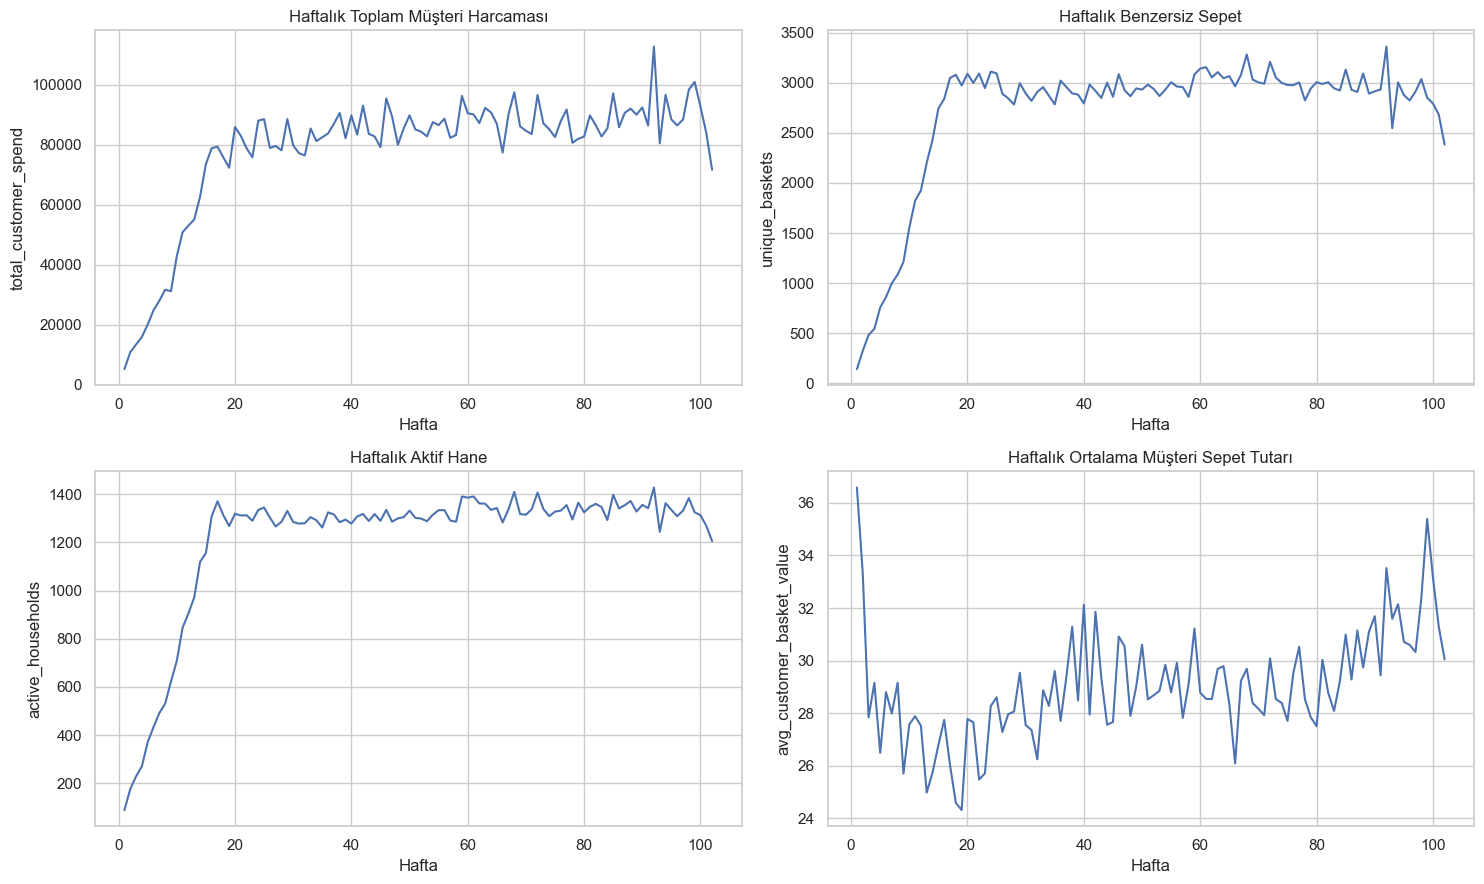

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

sns.lineplot(data=weekly_kpis, x="week_no", y="total_customer_spend", ax=axes[0, 0])
axes[0, 0].set_title("Haftalık Toplam Müşteri Harcaması")

sns.lineplot(data=weekly_kpis, x="week_no", y="unique_baskets", ax=axes[0, 1])
axes[0, 1].set_title("Haftalık Benzersiz Sepet")

sns.lineplot(data=weekly_kpis, x="week_no", y="active_households", ax=axes[1, 0])
axes[1, 0].set_title("Haftalık Aktif Hane")

sns.lineplot(data=weekly_kpis, x="week_no", y="avg_customer_basket_value", ax=axes[1, 1])
axes[1, 1].set_title("Haftalık Ortalama Müşteri Sepet Tutarı")

for ax in axes.flat:
    ax.set_xlabel("Hafta")

plt.tight_layout()
plt.show()


### Haftalık metriklere ilişkin bulgular

Toplam müşteri harcaması, benzersiz sepet sayısı ve aktif hane sayısı veri
döneminin ilk haftalarında birlikte artmaktadır. Ancak bu artış yalnızca mevcut
müşterilerin daha fazla alışveriş yaptığı anlamına gelmez. Aynı dönemde yeni
hanelerin veri paneline dahil olması, toplam metrikleri doğrudan yükseltmektedir.

Panel yaklaşık ilk 20 haftadan sonra daha kararlı bir yapıya ulaşmaktadır. Bu
dönemden sonra aktif hane ve sepet sayıları daha dar bir bantta hareket ederken
ortalama müşteri sepet tutarında haftalık dalgalanmalar devam etmektedir. Bu
durum toplam harcamadaki değişimin yalnızca müşteri sayısından değil, sepet
büyüklüğü ve ürün karmasından da kaynaklanabileceğini göstermektedir.

Aktif hane başına normalize edilen müşteri harcaması ve sepet sayısı, panel
büyüklüğünün etkisini azaltmaktadır. Dört haftalık hareketli ortalama ise kısa
süreli dalgalanmaları yumuşatarak temel davranış eğiliminin daha kolay
görülmesini sağlamaktadır.

Veri döneminin son haftalarında birden fazla metrikte görülen düşüş, gerçek
müşteri pasifleşmesinin yanında eksik dönem veya sağdan sansürlenme olasılığını
da düşündürmektedir.

### Hedef tasarımına etkisi

Hedef ve gözlem pencereleri belirlenirken:

1. Panelin henüz oluştuğu ilk haftalar,
2. Yeterli geçmişi bulunmayan geç girişli haneler,
3. Tam olarak gözlenmemiş olabilecek son haftalar

ayrı değerlendirilmelidir. Böylece veri kapsamındaki değişikliklerin müşteri
davranışı olarak yanlış yorumlanması önlenebilir.

## 7. Sepet düzeyinde EDA


In [18]:
basket_level = (
    transaction_data.groupby(
        ["basket_id", "household_key", "day", "week_no"],
        as_index=False,
    )
    .agg(
        basket_retailer_revenue=("retailer_revenue", "sum"),
        basket_customer_spend=("customer_paid_value", "sum"),
        basket_quantity=("quantity", "sum"),
        unique_products=("product_id", "nunique"),
        total_discount_amount=("total_discount_amount", "sum"),
        retail_discount_amount=(
            "retail_disc",
            lambda series: -series.sum()
        ),
        coupon_discount_amount=(
            "coupon_disc",
            lambda series: -series.sum()
        ),
        coupon_match_discount_amount=(
            "coupon_match_disc",
            lambda series: -series.sum()
        ),
    )
)

basket_level[
    [
        "basket_customer_spend",
        "basket_retailer_revenue",
        "basket_quantity",
        "unique_products",
        "total_discount_amount",
    ]
].describe(percentiles=[0.50, 0.90, 0.95, 0.99]).T


,count,mean,std,min,50%,90%,95%,99%,max
basket_customer_spend,"276,484.000",28.988,35.862,-7.000,17.000,70.210,101.100,173.103,961.490
basket_retailer_revenue,"276,484.000",29.143,36.101,0.000,17.070,70.647,101.640,174.123,961.490
basket_quantity,"276,484.000",942.860,"3,420.422",0.000,8.000,69.000,"9,555.000","16,743.000","89,638.000"
unique_products,"276,484.000",9.388,12.284,1.000,5.000,24.000,35.000,58.000,168.000
total_discount_amount,"276,484.000",5.239,8.651,-0.000,1.820,14.830,22.240,40.922,190.780


In [19]:
negative_baskets = (
    basket_level.loc[
        basket_level["basket_customer_spend"].lt(0)
    ]
    .sort_values("basket_customer_spend")
)

basket_payment_quality = pd.Series({
    "total_baskets": len(basket_level),
    "negative_customer_spend_baskets": len(negative_baskets),
    "zero_customer_spend_baskets": int(
        basket_level["basket_customer_spend"].eq(0).sum()
    ),
    "negative_basket_rate": (
        len(negative_baskets) / len(basket_level)
    ),
})

display(basket_payment_quality.to_frame("value"))
display(negative_baskets.head(20))

,value
total_baskets,"276,484.000"
negative_customer_spend_baskets,26.000
zero_customer_spend_baskets,980.000
negative_basket_rate,0.000


,basket_id,household_key,day,week_no,basket_retailer_revenue,basket_customer_spend,basket_quantity,unique_products,total_discount_amount,retail_discount_amount,coupon_discount_amount,coupon_match_discount_amount
46404,29194710070,2220,167,25,0.000,-7.000,0,2,7.000,-0.000,7.000,-0.000
45379,29170538060,2220,165,24,0.000,-6.000,0,2,6.000,-0.000,6.000,-0.000
195451,35333891053,443,518,75,0.000,-5.000,0,1,5.000,-0.000,5.000,-0.000
194909,35293613712,409,517,75,0.000,-5.000,0,1,5.000,-0.000,5.000,-0.000
220805,40436091832,1388,579,83,0.000,-3.190,0,2,3.190,-0.000,3.190,-0.000
2786,27432326713,1164,38,6,0.000,-3.000,0,1,3.000,-0.000,3.000,-0.000
109919,31769072118,2407,320,46,0.000,-2.500,0,1,2.500,-0.000,2.500,-0.000
152547,33180343833,909,420,61,3.780,-2.220,2,3,12.000,6.000,6.000,-0.000
166209,33658448479,2459,451,65,1.690,-1.310,2,3,3.790,0.790,3.000,-0.000
187182,34577721919,936,499,72,1.690,-1.210,1,2,3.000,0.100,2.900,-0.000


In [20]:
negative_basket_details = (
    transaction_product.loc[
        transaction_product["basket_id"].isin(
            negative_baskets["basket_id"]
        ),
        [
            "basket_id",
            "household_key",
            "day",
            "product_id",
            "sales_value",
            "retail_disc",
            "coupon_disc",
            "coupon_match_disc",
            "customer_paid_value",
            "department",
            "commodity_desc",
        ],
    ]
    .sort_values(["basket_id", "customer_paid_value"])
)

display(negative_basket_details.head(50))

,basket_id,household_key,day,product_id,sales_value,retail_disc,coupon_disc,coupon_match_disc,customer_paid_value,department,commodity_desc
28105,27432326713,1164,38,5978656,0.000,0.000,-3.000,0.000,-3.000,NaN,NaN
354059,28941321594,2049,151,5978656,0.000,0.000,-0.950,0.000,-0.950,NaN,NaN
354057,28941321594,2049,151,850841,0.950,0.000,-0.950,0.000,0.000,GROCERY,ISOTONIC DRINKS
354058,28941321594,2049,151,968932,0.000,-0.950,0.000,0.000,0.000,GROCERY,ISOTONIC DRINKS
403703,29170538060,2220,165,5978656,0.000,0.000,-6.000,0.000,-6.000,NaN,NaN
403702,29170538060,2220,165,5978648,0.000,0.000,0.000,0.000,0.000,NaN,NaN
413506,29194710070,2220,167,5978656,0.000,0.000,-7.000,0.000,-7.000,NaN,NaN
413505,29194710070,2220,167,5978648,0.000,0.000,0.000,0.000,0.000,NaN,NaN
515828,29672686275,1573,194,5978656,0.000,0.000,-1.000,0.000,-1.000,NaN,NaN
515827,29672686275,1573,194,850841,0.950,0.000,0.000,0.000,0.950,GROCERY,ISOTONIC DRINKS


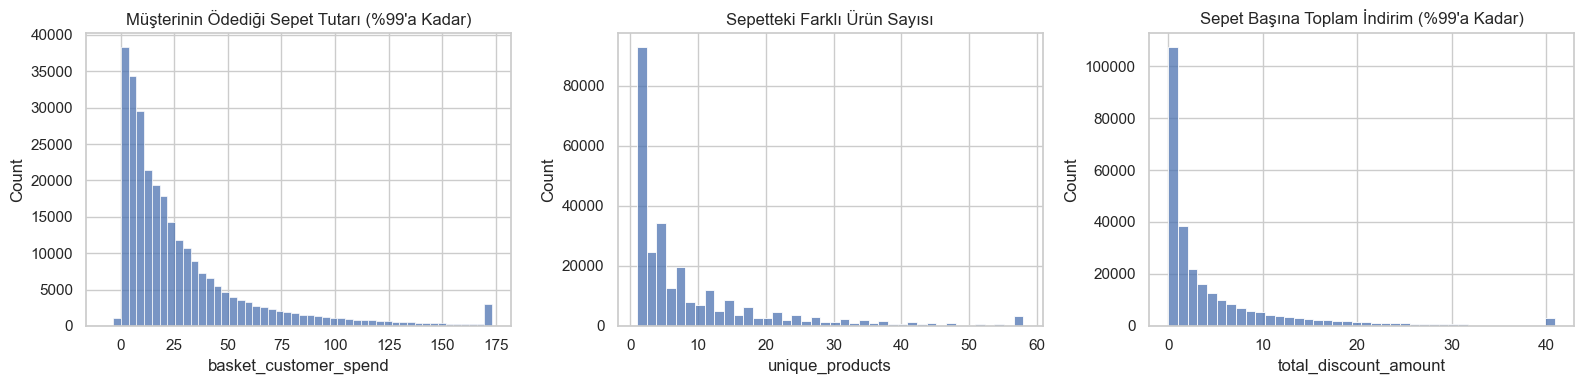

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(basket_level["basket_customer_spend"].clip(upper=basket_level["basket_customer_spend"].quantile(0.99)), bins=50, ax=axes[0])
axes[0].set_title("Müşterinin Ödediği Sepet Tutarı (%99'a Kadar)")

sns.histplot(basket_level["unique_products"].clip(upper=basket_level["unique_products"].quantile(0.99)), bins=40, ax=axes[1])
axes[1].set_title("Sepetteki Farklı Ürün Sayısı")

sns.histplot(
    basket_level["total_discount_amount"].clip(
        upper=basket_level["total_discount_amount"].quantile(0.99)
    ), bins=40, ax=axes[2]
)
axes[2].set_title("Sepet Başına Toplam İndirim (%99'a Kadar)")

plt.tight_layout()
plt.show()


### Sepet düzeyindeki bulgular

Veri setinde 276.484 benzersiz sepet bulunmaktadır. Müşterinin kupon sonrası
ödediği tahmini sepet tutarının ortalaması 28,99, medyanı 17,00 ve %99 yüzdeliği
yaklaşık 173,10'dur. Ortalama ile medyan arasındaki fark, dağılımın sağa çarpık
olduğunu göstermektedir.

Perakendecinin sepet başına ortalama geliri 29,14'tür. Bu değerin müşteri
harcamasından biraz daha yüksek olması, üretici kuponlarının müşterinin ödediği
tutarı azaltırken perakendeciye geri ödenmesinden kaynaklanmaktadır.

Bir sepetteki farklı ürün sayısının medyanı 5, ortalaması yaklaşık 9,4 ve %99
yüzdeliği 58'dir. Dolayısıyla az sayıdaki büyük ve ürün çeşitliliği yüksek sepet
ortalamayı yükseltmektedir. Sepet miktarı ise benzin işlemlerinden güçlü biçimde
etkilendiği için tek başına sepet büyüklüğü olarak yorumlanmamalıdır.

### Negatif ve sıfır tutarlı sepetler

Toplam 276.484 sepetin yalnızca 26'sında negatif müşteri harcaması görülmektedir.
Bu oran yaklaşık %0,009'dur. Ayrıca 980 sepetin müşteri harcaması sıfırdır.

Negatif sepetlerin çoğunda:

- Perakendeci geliri sıfır veya oldukça düşük,
- Miktar sıfır,
- Ayrı bir üretici kuponu satırı,
- Eksik ürün veya kategori bilgisi

bulunmaktadır. Bu örüntü, negatif değerlerin gerçek bir ürün satın alımından çok
kuponların işlem tablosunda ayrı satırlar hâlinde temsil edilmesiyle ilişkili
olduğunu göstermektedir.

Negatif sepetler veri setinin çok küçük bir bölümünü oluşturduğu için genel
dağılım üzerinde belirgin bir etkiye sahip değildir. Bununla birlikte bu kayıtlar
otomatik olarak silinmeyecek; modelleme aşamasında ham, sıfıra sınırlandırılmış
veya hariç tutulmuş tanımların sonuçları gerekirse duyarlılık analiziyle
karşılaştırılacaktır.

### Feature engineering açısından karar

Hane düzeyinde aşağıdaki sepet özellikleri üretilebilir:

- Ortalama ve medyan müşteri sepet tutarı,
- Ortalama farklı ürün sayısı,
- Sepet tutarının standart sapması,
- Büyük sepet oranı,
- Sıfır veya negatif tutarlı sepet oranı,
- İndirim kullanılan sepet oranı,
- Ortalama sepet indirimi,
- Son dönemdeki sepet tutarı değişimi.

## 8. Departman ve marka davranışı


In [22]:
department_summary = (
    transaction_product
    .dropna(subset=["department"])
    .groupby("department")
    .agg(
        total_customer_spend=("customer_paid_value", "sum"),
        total_retailer_revenue=("retailer_revenue", "sum"),
        total_discount_amount=("total_discount_amount", "sum"),
        transaction_lines=("product_id", "size"),
        unique_households=("household_key", "nunique"),
        unique_products=("product_id", "nunique"),
    )
    .sort_values("total_customer_spend", ascending=False)
    .reset_index()
)

brand_summary = (
    transaction_product
    .dropna(subset=["brand"])
    .groupby("brand")
    .agg(
        total_customer_spend=("customer_paid_value", "sum"),
        total_retailer_revenue=("retailer_revenue", "sum"),
        total_discount_amount=("total_discount_amount", "sum"),
        transaction_lines=("product_id", "size"),
        unique_households=("household_key", "nunique"),
    )
    .sort_values("total_customer_spend", ascending=False)
    .reset_index()
)

# Müşteri harcamasındaki paylar
department_summary["spend_share"] = (
    department_summary["total_customer_spend"]
    / department_summary["total_customer_spend"].sum()
)

department_summary["cumulative_spend_share"] = (
    department_summary["spend_share"].cumsum()
)

brand_summary["spend_share"] = (
    brand_summary["total_customer_spend"]
    / brand_summary["total_customer_spend"].sum()
)

display(department_summary.head(15))
display(brand_summary)

,department,total_customer_spend,total_retailer_revenue,total_discount_amount,transaction_lines,unique_households,unique_products,spend_share,cumulative_spend_share
0,GROCERY,"4,070,972.850","4,093,814.140","846,771.860",1646076,2500,39019,0.507,0.507
1,DRUG GM,"1,048,398.600","1,055,358.030","112,279.920",277232,2491,31523,0.131,0.638
2,PRODUCE,"557,047.690","557,452.110","68,904.310",257290,2456,3117,0.069,0.707
3,MEAT,"548,730.210","548,786.810","176,756.480",88416,2351,2544,0.068,0.776
4,KIOSK-GAS,"544,222.280","544,222.280","17,225.440",22059,1371,16,0.068,0.844
5,MEAT-PCKGD,"411,313.780","412,436.770","120,914.690",111957,2392,2427,0.051,0.895
6,DELI,"260,718.360","260,866.510","22,657.760",62787,2248,2354,0.032,0.927
7,PASTRY,"121,676.260","121,739.860","17,650.140",38179,2281,2149,0.015,0.942
8,MISC SALES TRAN,"119,960.040","119,960.040","3,035.690",6050,1393,88,0.015,0.957
9,NUTRITION,"97,470.220","97,669.040","12,452.040",32164,1719,2913,0.012,0.970


,brand,total_customer_spend,total_retailer_revenue,total_discount_amount,transaction_lines,unique_households,spend_share
0,National,"5,778,517.140","5,820,201.750","1,108,022.370",1849560,2500,0.721
1,Private,"2,236,334.400","2,237,261.330","340,499.820",746172,2496,0.279


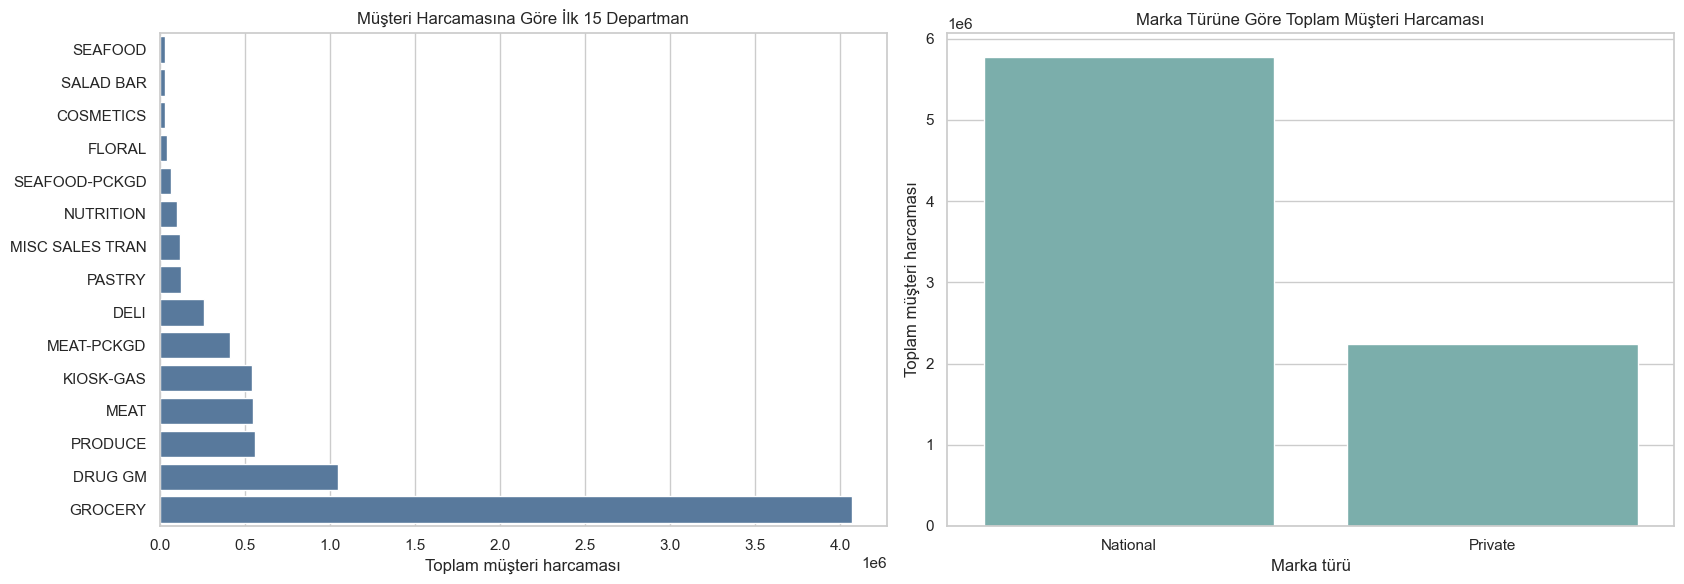

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Yatay grafikte en yüksek departmanın üstte görünmesi için
# ilk 15 departman kendi içinde küçükten büyüğe sıralanır.
top_departments = (
    department_summary
    .head(15)
    .sort_values("total_customer_spend", ascending=True)
)

sns.barplot(
    data=top_departments,
    x="total_customer_spend",
    y="department",
    color="#4C78A8",
    ax=axes[0],
)

axes[0].set_title("Müşteri Harcamasına Göre İlk 15 Departman")
axes[0].set_xlabel("Toplam müşteri harcaması")
axes[0].set_ylabel("")

sns.barplot(
    data=brand_summary,
    x="brand",
    y="total_customer_spend",
    color="#72B7B2",
    ax=axes[1],
)

axes[1].set_title("Marka Türüne Göre Toplam Müşteri Harcaması")
axes[1].set_xlabel("Marka türü")
axes[1].set_ylabel("Toplam müşteri harcaması")

plt.tight_layout()
plt.show()

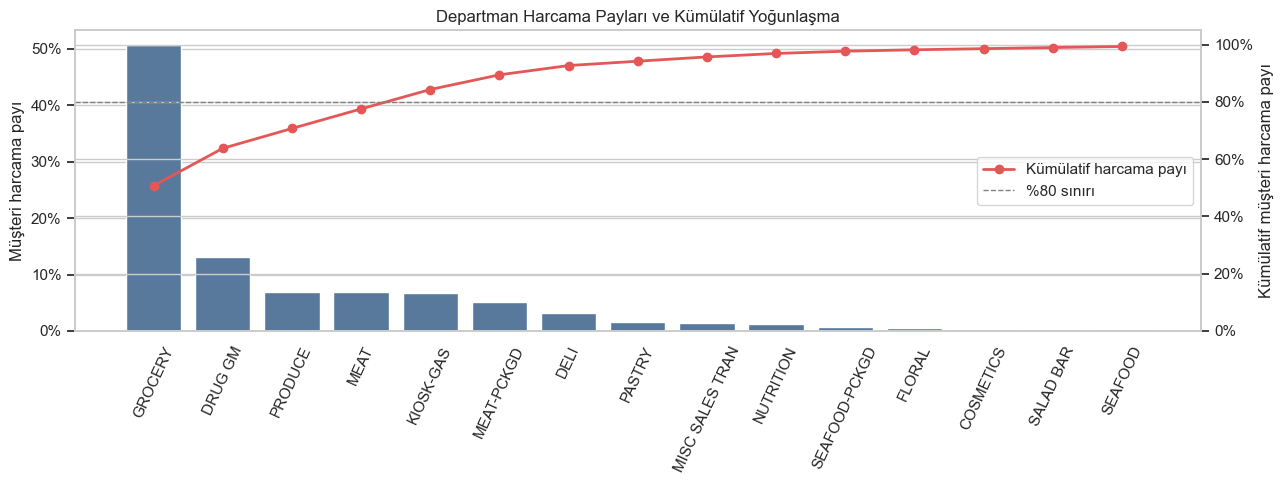

In [24]:
pareto = department_summary.head(15).copy()

fig, ax = plt.subplots(figsize=(13, 5))

sns.barplot(
    data=pareto,
    x="department",
    y="spend_share",
    color="#4C78A8",
    ax=ax,
)

ax.set_title("Departman Harcama Payları ve Kümülatif Yoğunlaşma")
ax.set_xlabel("")
ax.set_ylabel("Müşteri harcama payı")
ax.tick_params(axis="x", rotation=65)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Kümülatif pay için ikinci eksen
ax2 = ax.twinx()

ax2.plot(
    range(len(pareto)),
    pareto["cumulative_spend_share"],
    color="#E45756",
    marker="o",
    linewidth=2,
    label="Kümülatif harcama payı",
)

ax2.axhline(
    0.80,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="%80 sınırı",
)

ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Kümülatif müşteri harcama payı")
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.legend(loc="center right")

plt.tight_layout()
plt.show()

### Departman ve marka davranışına ilişkin bulgular

`GROCERY`, yaklaşık 4,07 milyon müşteri harcamasıyla toplam harcamanın %50,7'sini
tek başına oluşturmaktadır. İlk beş departman olan `GROCERY`, `DRUG GM`,
`PRODUCE`, `MEAT` ve `KIOSK-GAS` birlikte toplam müşteri harcamasının yaklaşık
%84,4'ünü açıklamaktadır. Bu sonuç, harcamaların az sayıdaki departmanda
yoğunlaştığını göstermektedir.

`KIOSK-GAS`, yalnızca 16 farklı ürün içermesine rağmen toplam müşteri harcamasının
yaklaşık %6,8'ini oluşturmaktadır. Bu durum departmanın standart market
kategorilerinden farklı bir miktar ve satış yapısına sahip olduğunu
doğrulamaktadır.

National marka ürünleri yaklaşık 5,78 milyon ile müşteri harcamasının %72,1'ini,
Private marka ürünleri ise yaklaşık 2,24 milyon ile %27,9'unu oluşturmaktadır.
Ancak bu oranlar doğrudan müşteri tercihi olarak yorumlanmamalıdır. Sonuçlar
kategori yapısı, ürün çeşitliliği ve ürünlerin veri setindeki bulunabilirliğinden
de etkilenebilir.

### Feature engineering açısından karar

Toplam kategori harcamalarının doğrudan kullanılması, yüksek harcama yapan
hanelerin bütün kategori değişkenlerinde yüksek değer almasına neden olabilir.
Bu nedenle aşağıdaki oransal özellikler daha açıklayıcı olabilir:

- Grocery harcamasının toplam harcamaya oranı,
- Benzin harcamasının toplam harcamaya oranı,
- Taze ürün ve et kategorilerinin harcama payı,
- Private marka harcama ve işlem oranı,
- En sık tercih edilen departman,
- Farklı departman sayısı,
- Toplam harcamanın ilk üç departmanda yoğunlaşma oranı.

## 9. Hane düzeyinde davranış profili

Modelin tahmin birimi işlem satırı değil, hanedir. Bu nedenle temel davranış
göstergeleri hane düzeyinde özetlenir. Buradaki tablo yalnızca EDA amaçlıdır; nihai
özellik tablosunda gözlem döneminin son günü ayrıca tanımlanacaktır.


In [25]:
data_end_day = int(transaction_data["day"].max())

household_behavior = (
    transaction_product.groupby("household_key")
    .agg(
        first_purchase_day=("day", "min"),
        last_purchase_day=("day", "max"),
        frequency=("basket_id", "nunique"),
        monetary=("customer_paid_value", "sum"),
        retailer_revenue=("retailer_revenue", "sum"),
        total_discount_amount=("total_discount_amount", "sum"),
        active_days=("day", "nunique"),
        active_weeks=("week_no", "nunique"),
        unique_products=("product_id", "nunique"),
        unique_departments=("department", "nunique"),
        total_retail_discount=("retail_disc", "sum"),
        total_coupon_discount=("coupon_disc", "sum"),
        total_coupon_match_discount=("coupon_match_disc", "sum"),
    )
    .reset_index()
)

household_behavior["recency"] = data_end_day - household_behavior["last_purchase_day"]
household_behavior["avg_basket_value"] = household_behavior["monetary"] / household_behavior["frequency"]
household_behavior["purchase_span"] = (
    household_behavior["last_purchase_day"] - household_behavior["first_purchase_day"]
)
household_behavior["discount_to_spend_ratio"] = (
    household_behavior["total_discount_amount"]
    / (
        household_behavior["monetary"]
        + household_behavior["total_discount_amount"]
    )
).replace([np.inf, -np.inf], np.nan)

household_behavior.describe(percentiles=[0.50, 0.90, 0.95, 0.99]).T


,count,mean,std,min,50%,90%,95%,99%,max
household_key,"2,500.000","1,250.500",721.832,1.000,"1,250.500","2,250.100","2,375.050","2,475.010","2,500.000"
first_purchase_day,"2,500.000",65.941,39.152,1.000,69.000,110.000,115.000,118.000,671.000
last_purchase_day,"2,500.000",685.426,62.791,54.000,705.000,711.000,711.000,711.000,711.000
frequency,"2,500.000",110.594,115.669,1.000,79.000,229.100,321.000,553.100,"1,300.000"
monetary,"2,500.000","3,205.941","3,330.002",8.170,"2,149.115","7,434.071","9,558.397","15,242.221","38,240.650"
retailer_revenue,"2,500.000","3,222.985","3,349.026",8.170,"2,157.750","7,448.216","9,754.144","15,325.025","38,319.790"
total_discount_amount,"2,500.000",579.409,593.602,0.250,396.275,"1,316.492","1,771.932","2,733.197","5,162.450"
active_days,"2,500.000",90.213,76.317,1.000,70.000,189.000,245.000,371.020,521.000
active_weeks,"2,500.000",49.590,25.543,1.000,50.000,84.000,90.000,97.000,102.000
unique_products,"2,500.000",560.588,435.958,4.000,455.000,"1,147.100","1,405.000","1,973.210","3,159.000"


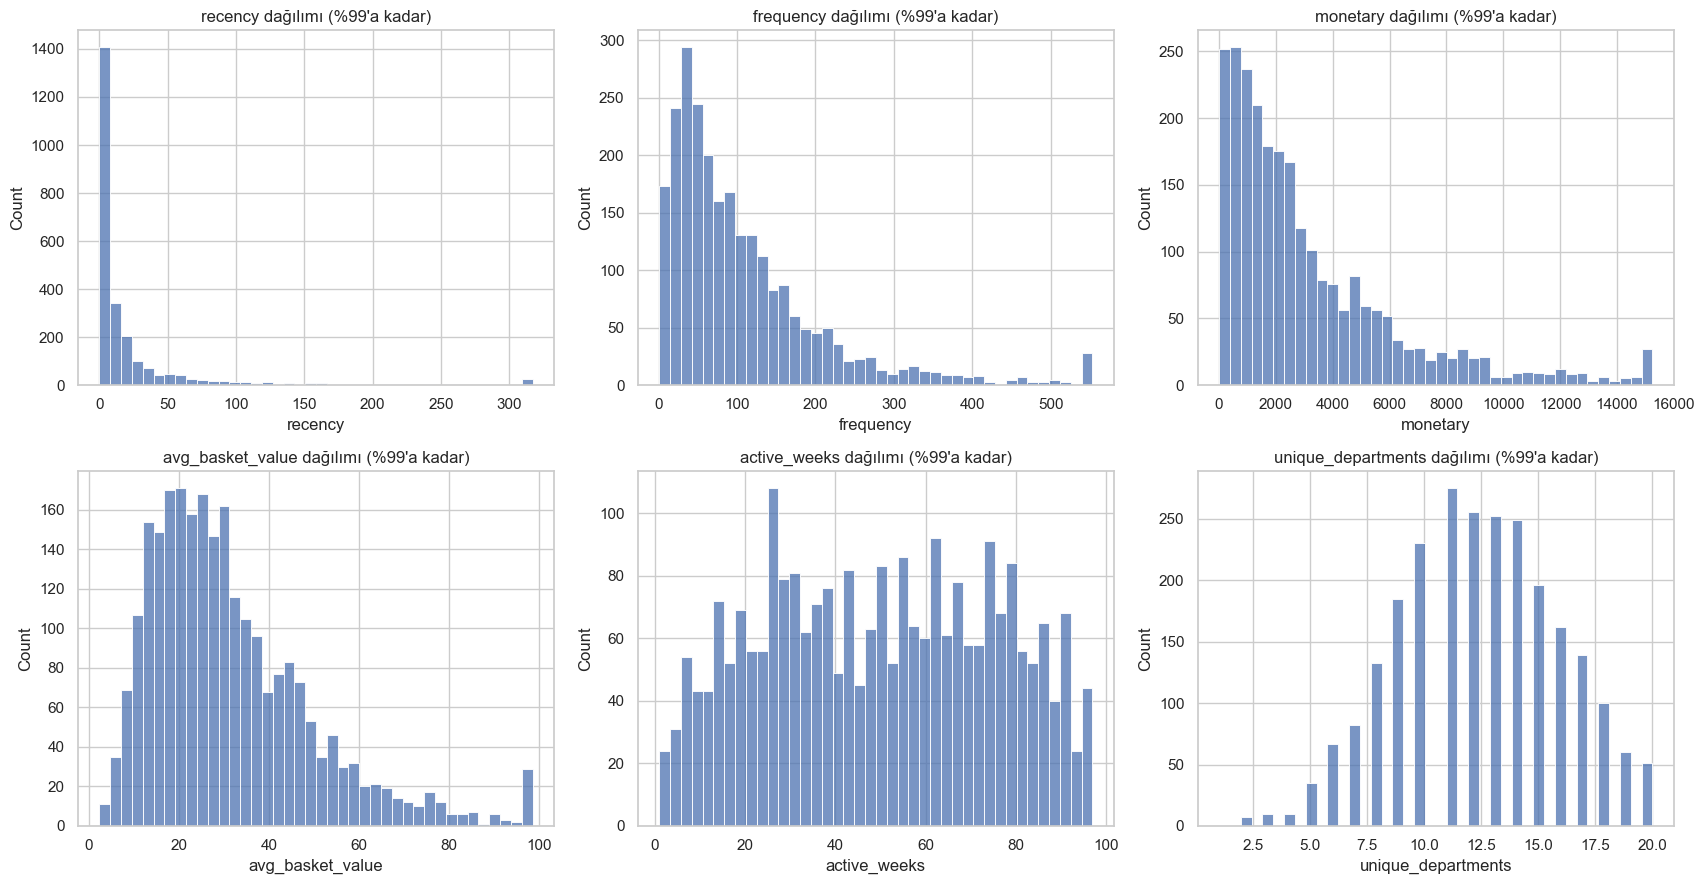

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
plot_cols = [
    "recency", "frequency", "monetary",
    "avg_basket_value", "active_weeks", "unique_departments",
]

for ax, col in zip(axes.flat, plot_cols):
    upper = household_behavior[col].quantile(0.99)
    sns.histplot(household_behavior[col].clip(upper=upper), bins=40, ax=ax)
    ax.set_title(f"{col} dağılımı (%99'a kadar)")

plt.tight_layout()
plt.show()


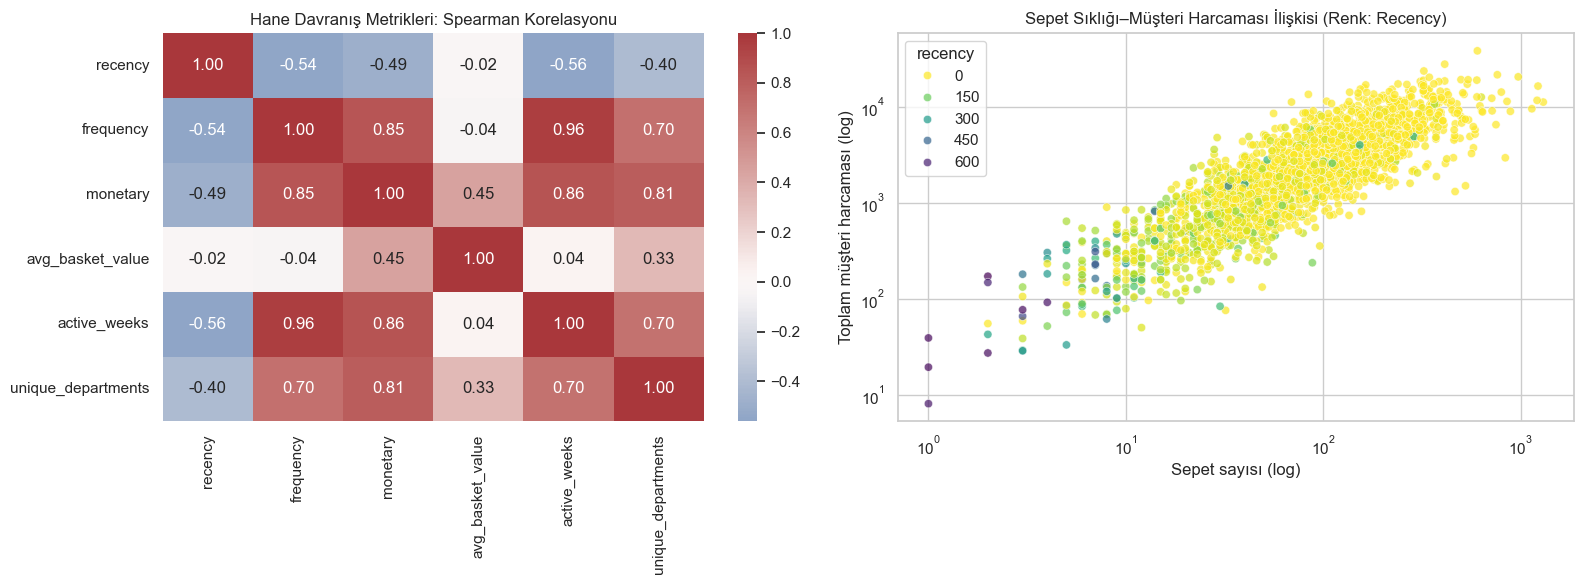

In [27]:
rfm_cols = ["recency", "frequency", "monetary", "avg_basket_value", "active_weeks", "unique_departments"]
rfm_corr = household_behavior[rfm_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(rfm_corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Hane Davranış Metrikleri: Spearman Korelasyonu")

sns.scatterplot(
    data=household_behavior, x="frequency", y="monetary",
    hue="recency", palette="viridis_r", alpha=0.70, ax=axes[1]
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title(
    "Sepet Sıklığı–Müşteri Harcaması İlişkisi (Renk: Recency)")
axes[1].set_xlabel("Sepet sayısı (log)")
axes[1].set_ylabel("Toplam müşteri harcaması (log)")

plt.tight_layout()
plt.show()


### Hane davranış profiline ilişkin bulgular

Hanelerin medyan sepet sayısı 79, medyan müşteri harcaması 2.149,12 ve medyan
ortalama sepet tutarı 27,36'dır. Frequency ve monetary değişkenlerinde ortalamanın
medyandan yüksek olması, az sayıdaki çok aktif ve yüksek harcamalı hanenin
dağılımın sağ kuyruğunu oluşturduğunu göstermektedir.

Medyan recency değeri 6 gün olmasına rağmen ortalama recency yaklaşık 25,6 gündür.
Bu fark, müşterilerin büyük bölümünün veri döneminin sonuna yakın alışveriş
yaptığını; ancak uzun süredir alışveriş yapmayan daha küçük bir hane grubunun
bulunduğunu göstermektedir. Bu nedenle recency, pasifleşme tahmini açısından
önemli bir aday değişkendir.

Hanelerin medyan indirim/harcama oranı yaklaşık %15,1'dir. %90 yüzdeliğinde bu
oran yaklaşık %22,6'ya, %99 yüzdeliğinde ise %32,6'ya çıkmaktadır. Bu farklılık,
indirim duyarlılığının haneler arasında ayırt edici bir davranış olabileceğini
göstermektedir.

Spearman korelasyon matrisi frequency, monetary ve active weeks değişkenlerinin
benzer müşteri aktivitesi bilgisini taşıdığını göstermektedir. Ortalama sepet
tutarının frequency ile daha düşük ilişki göstermesi ise sepet büyüklüğünün
alışveriş sıklığından farklı ve tamamlayıcı bir davranış boyutu olduğunu
düşündürmektedir.

Yüksek korelasyonlu özellikler aynı davranışın farklı ifadeleri olabilir. Ağaç
tabanlı modeller bu ilişkileri daha esnek biçimde yönetebilse de lojistik
regresyon gibi doğrusal modellerde düzenlileştirme, özellik seçimi veya çoklu
bağlantı kontrolü gerekebilir.

> Buradaki RFM metrikleri bütün veri dönemi kullanılarak yalnızca EDA amacıyla
> hesaplanmıştır. Nihai özellik tablosunda recency ve diğer davranış değişkenleri
> sadece gözlem penceresinin son gününe göre yeniden hesaplanacaktır.

## 10. Sonuç ve feature engineering'e aktarılacak bulgular

### Veri kapsamı

| Gösterge | Değer |
|---|---:|
| İşlem satırı | 2.595.732 |
| Benzersiz sepet | 276.484 |
| Hane | 2.500 |
| Ürün | 92.353 |
| İşlem dönemi | 102 hafta |

### Temel bulgular

- Müşterinin kupon sonrası ödediği tahmini sepet tutarının ortalaması 28,99,
  medyanı 17,00'dır. Perakendecinin sepet başına ortalama geliri ise 29,14'tür.
  Aradaki fark üretici kuponlarının geri ödeme yapısından kaynaklanmaktadır.
- 5.819 işlem satırında negatif müşteri ödeme tutarı vardır. Bunların büyük bölümü
  sıfır satış ve sıfır miktar içeren ayrı kupon kayıtlarıdır.
- Sepet düzeyinde yalnızca 26 negatif harcama kaydı bulunmaktadır. Bu sepetler
  toplam sepetlerin yaklaşık %0,009'unu oluşturur ve ayrı bir veri kalite grubu
  olarak korunmuştur.
- `quantity` medyanı 1 iken maksimumu 89.638'dir. En yüksek miktarlı işlemler
  benzin ürünlerine aittir; bu nedenle bütün ürünlere ortak miktar sınırı
  uygulanmayacaktır.
- İşlem–ürün birleşmesi satır sayısını değiştirmemiştir. Departman bilgisi
  bulunmayan 7.839 işlem, ürün eşleşme probleminden değil ürün tablosundaki eksik
  kategori bilgilerinden kaynaklanmaktadır.
- `GROCERY`, yaklaşık 4,07 milyon ve %50,7 pay ile müşteri harcamasının en büyük
  departmanıdır. İlk beş departman toplam müşteri harcamasının yaklaşık %84,4'ünü
  oluşturmaktadır.
- National marka ürünleri müşteri harcamasının yaklaşık %72,1'ini, Private marka
  ürünleri ise %27,9'unu oluşturmaktadır.
- Hane düzeyinde medyan sepet sayısı 79, medyan müşteri harcaması 2.149,12,
  medyan recency 6 gün ve medyan aktif hafta sayısı 50'dir.
- Medyan indirim/harcama oranı yaklaşık %15,1'dir. Bu değişken müşteri indirim
  duyarlılığını temsil edebilecek bir feature adayıdır.
- İlk haftalardaki toplam büyüme panel katılımından etkilenmektedir. Hedef
  tasarımında geç girişli haneler ve tam gözlenemeyen son dönemler ayrıca
  değerlendirilmelidir.

### Feature engineering'e aktarılacak özellik grupları

- **RFM:** Recency, frequency ve müşteri tarafından ödenen monetary değer
- **Sepet:** Ortalama/medyan sepet tutarı, ürün çeşitliliği ve büyük sepet oranı
- **Düzenlilik:** Aktif gün, aktif hafta ve alışveriş aralığı istatistikleri
- **Kategori:** Departman çeşitliliği ve kategori harcama payları
- **Marka:** Private/National marka harcama ve işlem oranları
- **İndirim:** İndirimli işlem/sepet oranı ve indirim–harcama oranı
- **Zaman:** Alışveriş saati tercihleri ve yakın dönem davranış eğilimleri
- **Panel geçmişi:** İlk alışveriş günü ve gözlenen müşteri geçmişinin uzunluğu
- **Trend:** Son 4/8/12 haftanın önceki dönemlere göre harcama ve sıklık değişimi

### Modelleme öncesinde korunacak kararlar

1. Yüksek miktarlı benzin işlemleri otomatik olarak silinmeyecektir.
2. Kuponların ayrı satırlarda gösterilmesinden kaynaklanan negatif ödeme
   kayıtları iş bağlamı incelenmeden temizlenmeyecektir.
3. Kategori bilgisi bulunmayan işlemler mümkün olduğunda `Unknown` olarak temsil
   edilecektir.
4. Hane metrikleri bütün dönemden değil, yalnızca gözlem penceresinden yeniden
   üretilecektir.
5. Geç girişli haneler ve veri döneminin sonundaki eksik gözlem riski hedef
   tasarımında ayrıca ele alınacaktır.

**Sonraki adım:** `03_eda_customers_and_demographics.ipynb` ile demografik
kapsama, temsil farklılıkları ve demografik özelliklerin müşteri davranışıyla
ilişkisi incelenecektir.